# Group by in pandas 

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

df = pd.read_excel("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/weather_data_5_cities.xlsx")
df

,City,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
0,New York,2025-01-01,14.0,42.7,13.8,12.2
1,New York,2025-01-02,29.4,77.1,12.2,11.3
2,New York,2025-01-03,26.7,69.0,17.5,9.6
3,New York,2025-01-04,30.4,58.6,2.1,12.9
4,New York,2025-01-05,10.4,41.4,1.9,12.3
5,New York,2025-01-06,23.5,72.2,15.7,7.3
6,New York,2025-01-07,23.7,35.5,3.9,11.9
7,New York,2025-01-08,30.8,45.1,2.7,3.9
8,New York,2025-01-09,28.8,37.7,17.4,6.3
9,New York,2025-01-10,31.5,89.6,2.3,5.2


## Find maximum temperature, windspeed, precipitation and humidity in each of the cities.
Here I am trying to group the data per city and then I want to run analytics for each of these groups. <br>
For such a usecase it makes sense to use pandas group by feature.

In [2]:
group_by_cities_df = df.groupby("City")
group_by_cities_df

### So what is inside this group_by pandas object : <pandas.core.groupby.generic.DataFrameGroupBy object at 0x7fc0c725f100>
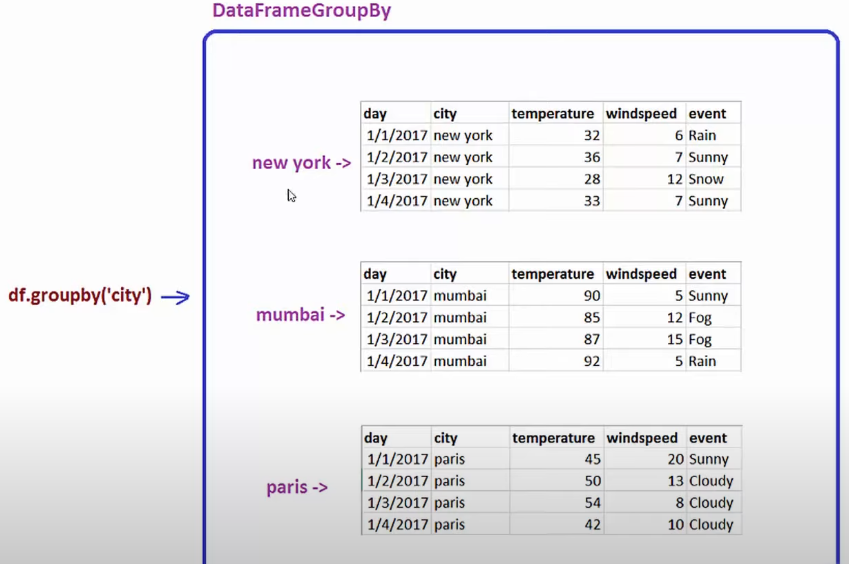 <br>
So when you say dataFrame groupby city then pandas will create the object as shown in the above figure, where you have keys and values, So here my key is New York and my value is a dataFrame containing Newyork city's data. Same way I have key and data for Mumbai and Paris.

In [3]:
for city, city_df in group_by_cities_df:
    print(city)
    print(city_df)

London
      City       Date  Temperature_C  Humidity_%  WindSpeed_kmph  \
10  London 2025-01-01           13.3        42.9            11.4   
11  London 2025-01-02            0.5        43.1             7.8   
12  London 2025-01-03            7.9        84.0             0.6   
13  London 2025-01-04           11.9        53.0             7.3   
14  London 2025-01-05            0.9        65.2             1.6   
15  London 2025-01-06            0.8        65.7             2.4   
16  London 2025-01-07           13.7        60.8            14.8   
17  London 2025-01-08           10.1        80.1            17.2   
18  London 2025-01-09           30.8        58.4            15.1   
19  London 2025-01-10            9.2        46.8             0.3   

    Precipitation_mm  
10              14.4  
11               2.1  
12               3.7  
13               3.7  
14              10.7  
15              11.2  
16               6.0  
17               2.6  
18               7.9  
19            

### If you want to access a specific dataFrame of a particular city then you can do something like this
- ```group_by_cities_df.get_group("Mumbai")``` As you know the group_by_cities_df is an object created by pandas where city names are the keys and their values are the dataFrame containing the weather data of those respective cities. By providing the key i.e city name here in this case you will be able to access the dataFrame associated with that city.
- This statement in pandas ```group_by_cities_df.get_group("Mumbai")``` is similar to this SQL statement ```SELECT * FROM city_data GROUP BY city```. This SQL statement is gonna give you similar result, where it will group the data by the cities.

#### Access the dataFrame of Mumbai city

In [4]:
mumbai_df = group_by_cities_df.get_group("Mumbai")
mumbai_df

,City,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
30,Mumbai,2025-01-01,2.2,35.5,0.8,13.6
31,Mumbai,2025-01-02,9.0,68.2,17.2,0.8
32,Mumbai,2025-01-03,15.9,64.9,18.1,4.4
33,Mumbai,2025-01-04,21.5,38.2,17.8,4.7
34,Mumbai,2025-01-05,13.1,41.8,16.1,0.3
35,Mumbai,2025-01-06,32.7,57.7,16.2,8.9
36,Mumbai,2025-01-07,20.8,57.1,3.4,0.4
37,Mumbai,2025-01-08,31.0,80.7,5.9,11.9
38,Mumbai,2025-01-09,34.3,51.0,17.9,9.9
39,Mumbai,2025-01-10,9.3,73.4,13.7,12.1


#### Get the maximum temperature , humidity windspeed and precipitation in mumbai city.

In [5]:
mumbai_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].max()

Temperature_C       34.3
Humidity_%          80.7
WindSpeed_kmph      18.1
Precipitation_mm    13.6
dtype: float64

#### Access the dataFrame of New York city

In [6]:
newyork_df = group_by_cities_df.get_group("New York")
newyork_df

,City,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
0,New York,2025-01-01,14.0,42.7,13.8,12.2
1,New York,2025-01-02,29.4,77.1,12.2,11.3
2,New York,2025-01-03,26.7,69.0,17.5,9.6
3,New York,2025-01-04,30.4,58.6,2.1,12.9
4,New York,2025-01-05,10.4,41.4,1.9,12.3
5,New York,2025-01-06,23.5,72.2,15.7,7.3
6,New York,2025-01-07,23.7,35.5,3.9,11.9
7,New York,2025-01-08,30.8,45.1,2.7,3.9
8,New York,2025-01-09,28.8,37.7,17.4,6.3
9,New York,2025-01-10,31.5,89.6,2.3,5.2


#### Get the maximum temperature, humidity , windspeed and precipitation in new york city.

In [7]:
newyork_df[["Temperature_C", "Humidity_%", "WindSpeed_kmph", "Precipitation_mm"]].max()

Temperature_C       31.5
Humidity_%          89.6
WindSpeed_kmph      17.5
Precipitation_mm    12.9
dtype: float64

#### Access the dataFrame of Tokyo city

In [8]:
tokyo_df = group_by_cities_df.get_group("Tokyo")
tokyo_df

,City,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
20,Tokyo,2025-01-01,25.1,65.2,10.1,14.9
21,Tokyo,2025-01-02,31.9,42.4,10.6,2.6
22,Tokyo,2025-01-03,10.3,64.2,9.5,5.7
23,Tokyo,2025-01-04,12.2,48.5,5.1,8.6
24,Tokyo,2025-01-05,3.1,32.4,5.7,10.2
25,Tokyo,2025-01-06,21.2,33.1,3.3,4.7
26,Tokyo,2025-01-07,1.1,41.1,12.5,9.8
27,Tokyo,2025-01-08,2.9,49.6,7.1,11.8
28,Tokyo,2025-01-09,21.8,62.5,2.2,6.8
29,Tokyo,2025-01-10,4.6,72.7,16.2,9.4


#### Get the maximum temperature, humidity , windspeed and precipitation in tokyo city.

In [9]:
tokyo_df[["Temperature_C", "Humidity_%", "WindSpeed_kmph", "Precipitation_mm"]].max()

Temperature_C       31.9
Humidity_%          72.7
WindSpeed_kmph      16.2
Precipitation_mm    14.9
dtype: float64

#### Access the dataFrame of Sydney city

In [10]:
sydney_df = group_by_cities_df.get_group("Sydney")
sydney_df

,City,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
40,Sydney,2025-01-01,26.2,36.4,3.1,7.2
41,Sydney,2025-01-02,11.0,74.8,14.0,12.6
42,Sydney,2025-01-03,32.1,59.9,6.9,11.9
43,Sydney,2025-01-04,20.8,34.0,2.0,4.6
44,Sydney,2025-01-05,24.5,42.8,14.3,5.8
45,Sydney,2025-01-06,17.5,67.9,18.5,10.4
46,Sydney,2025-01-07,13.8,74.5,3.2,11.9
47,Sydney,2025-01-08,9.2,77.2,0.1,5.5
48,Sydney,2025-01-09,29.0,50.3,14.3,6.9
49,Sydney,2025-01-10,23.2,69.1,5.2,3.9


#### Get the maximum temperature, humidity, windspeed and precipitation in sydney city

In [11]:
sydney_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].max()

Temperature_C       32.1
Humidity_%          77.2
WindSpeed_kmph      18.5
Precipitation_mm    12.6
dtype: float64

#### Access the dataFrame of London city

In [12]:
london_df = group_by_cities_df.get_group("London")
london_df

,City,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
10,London,2025-01-01,13.3,42.9,11.4,14.4
11,London,2025-01-02,0.5,43.1,7.8,2.1
12,London,2025-01-03,7.9,84.0,0.6,3.7
13,London,2025-01-04,11.9,53.0,7.3,3.7
14,London,2025-01-05,0.9,65.2,1.6,10.7
15,London,2025-01-06,0.8,65.7,2.4,11.2
16,London,2025-01-07,13.7,60.8,14.8,6.0
17,London,2025-01-08,10.1,80.1,17.2,2.6
18,London,2025-01-09,30.8,58.4,15.1,7.9
19,London,2025-01-10,9.2,46.8,0.3,9.1


#### Get the maximum temperature, humidity, windspeed and precipitation in london city

In [13]:
london_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].max()

Temperature_C       30.8
Humidity_%          84.0
WindSpeed_kmph      17.2
Precipitation_mm    14.4
dtype: float64

## Find minimum temperature , humidity windspeed and precipitation in each of the cities.

#### Get the minimum temperature, humidity, precipitation and windspeed of Mumbai city

In [14]:
mumbai_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].min()

Temperature_C        2.2
Humidity_%          35.5
WindSpeed_kmph       0.8
Precipitation_mm     0.3
dtype: float64

#### Get the minimum temperature, humidity, precipitation and windspeed of New York city

In [15]:
newyork_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].min()

Temperature_C       10.4
Humidity_%          35.5
WindSpeed_kmph       1.9
Precipitation_mm     3.9
dtype: float64

#### Get the minimum temperature , humidity , windspeed and precipitation of London city

In [16]:
london_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].min()

Temperature_C        0.5
Humidity_%          42.9
WindSpeed_kmph       0.3
Precipitation_mm     2.1
dtype: float64

#### Get the minimum temperature, humidity, windspeed and precipiration of Tokyo city

In [17]:
tokyo_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].min()

Temperature_C        1.1
Humidity_%          32.4
WindSpeed_kmph       2.2
Precipitation_mm     2.6
dtype: float64

#### Get the minimum temperature, humidity, windspeed and precipitation of sydney city

In [18]:
sydney_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].min()

Temperature_C        9.2
Humidity_%          34.0
WindSpeed_kmph       0.1
Precipitation_mm     3.9
dtype: float64

## Find average (mean) temperature, windspeed, humidity and precipitation per city

#### Get the average (mean) of temperature, humidity, precipitation and windspeed of Mumbai city 

In [19]:
mumbai_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mean()

Temperature_C       18.98
Humidity_%          56.85
WindSpeed_kmph      12.71
Precipitation_mm     6.70
dtype: float64

#### Get the average (mean) of temperature, windspeed, humidity and precipitation of Tokyo city

In [20]:
tokyo_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mean()

Temperature_C       13.42
Humidity_%          51.17
WindSpeed_kmph       8.23
Precipitation_mm     8.45
dtype: float64

#### Get the average (mean) of temperature, humidity , windspeed and precipitation of Syndey city

In [21]:
sydney_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mean()

Temperature_C       20.73
Humidity_%          58.69
WindSpeed_kmph       8.16
Precipitation_mm     8.07
dtype: float64

#### Get the average (mean) of temperature , humidity , windspeed and precipitation of New York city

In [22]:
newyork_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mean()

Temperature_C       24.92
Humidity_%          56.89
WindSpeed_kmph       8.95
Precipitation_mm     9.29
dtype: float64

#### Get the average (mean) of temperature, humidity ,  windspeed and precipitation of London city

In [23]:
london_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mean()

Temperature_C        9.91
Humidity_%          60.00
WindSpeed_kmph       7.85
Precipitation_mm     7.14
dtype: float64

## Find the median of temperature, humidty, windspeed and precipitation of each cities 

#### Get the median of temperature , humidity , windspeed and precipitation of Mumbai city

In [24]:
mumbai_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].median()

Temperature_C       18.35
Humidity_%          57.40
WindSpeed_kmph      16.15
Precipitation_mm     6.80
dtype: float64

#### Get the median of temperature , humidity , windspeed and precipitation of Tokyo city

In [25]:
tokyo_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].median()

Temperature_C       11.25
Humidity_%          49.05
WindSpeed_kmph       8.30
Precipitation_mm     9.00
dtype: float64

#### Get the median of temperature, humidity, windspeed and precipitation of Sydney city

In [26]:
sydney_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].median()

Temperature_C       22.00
Humidity_%          63.90
WindSpeed_kmph       6.05
Precipitation_mm     7.05
dtype: float64

#### Get the median of temperature, humidity, windspeed and precipitation of London city

In [27]:
london_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].median()

Temperature_C        9.65
Humidity_%          59.60
WindSpeed_kmph       7.55
Precipitation_mm     6.95
dtype: float64

#### Get the median of temperature, humidity, windspeed and precipitation of New York city

In [28]:
newyork_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].median()

Temperature_C       27.75
Humidity_%          51.85
WindSpeed_kmph       8.05
Precipitation_mm    10.45
dtype: float64

## Find the mode of temperature, humidity, windspeed and precipitation of each of the cities

#### Get the mode of temperature , humidity , precipitation and windspeed of Mumbai city

In [29]:
mumbai_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mode()

,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
0,2.2,35.5,0.8,0.3
1,9.0,38.2,3.4,0.4
2,9.3,41.8,5.9,0.8
3,13.1,51.0,13.7,4.4
4,15.9,57.1,16.1,4.7
5,20.8,57.7,16.2,8.9
6,21.5,64.9,17.2,9.9
7,31.0,68.2,17.8,11.9
8,32.7,73.4,17.9,12.1
9,34.3,80.7,18.1,13.6


#### Get the mode of temperature, humidity, precipitation and windspeed of Tokyo city

In [30]:
tokyo_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mode()

,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
0,1.1,32.4,2.2,2.6
1,2.9,33.1,3.3,4.7
2,3.1,41.1,5.1,5.7
3,4.6,42.4,5.7,6.8
4,10.3,48.5,7.1,8.6
5,12.2,49.6,9.5,9.4
6,21.2,62.5,10.1,9.8
7,21.8,64.2,10.6,10.2
8,25.1,65.2,12.5,11.8
9,31.9,72.7,16.2,14.9


#### Get the mode of temperature, humidity , windspeed and precipitation of Sydney city

In [31]:
sydney_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mode()

,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
0,9.2,34.0,14.3,11.9
1,11.0,36.4,NaN,NaN
2,13.8,42.8,NaN,NaN
3,17.5,50.3,NaN,NaN
4,20.8,59.9,NaN,NaN
5,23.2,67.9,NaN,NaN
6,24.5,69.1,NaN,NaN
7,26.2,74.5,NaN,NaN
8,29.0,74.8,NaN,NaN
9,32.1,77.2,NaN,NaN


#### Get the mode of temperature, humidity, windspeed and precipitation of New York city

In [32]:
newyork_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mode()

,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
0,10.4,35.5,1.9,3.9
1,14.0,37.7,2.1,5.2
2,23.5,41.4,2.3,6.3
3,23.7,42.7,2.7,7.3
4,26.7,45.1,3.9,9.6
5,28.8,58.6,12.2,11.3
6,29.4,69.0,13.8,11.9
7,30.4,72.2,15.7,12.2
8,30.8,77.1,17.4,12.3
9,31.5,89.6,17.5,12.9


#### Get the mode of temperature, humidity, windspeed and Precipitation of London city

In [33]:
london_df[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mode()

,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
0,0.5,42.9,0.3,3.7
1,0.8,43.1,0.6,NaN
2,0.9,46.8,1.6,NaN
3,7.9,53.0,2.4,NaN
4,9.2,58.4,7.3,NaN
5,10.1,60.8,7.8,NaN
6,11.9,65.2,11.4,NaN
7,13.3,65.7,14.8,NaN
8,13.7,80.1,15.1,NaN
9,30.8,84.0,17.2,NaN


## Lets see how to calculate min(), max(), mean(), mode(), median() and show the results of all the cities in a single dataFrame

#### Here I will be creating a new dataFrame for this demo

In [34]:
df2 = pd.read_excel("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/weather_data_5_cities.xlsx")
df2

,City,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
0,New York,2025-01-01,14.0,42.7,13.8,12.2
1,New York,2025-01-02,29.4,77.1,12.2,11.3
2,New York,2025-01-03,26.7,69.0,17.5,9.6
3,New York,2025-01-04,30.4,58.6,2.1,12.9
4,New York,2025-01-05,10.4,41.4,1.9,12.3
5,New York,2025-01-06,23.5,72.2,15.7,7.3
6,New York,2025-01-07,23.7,35.5,3.9,11.9
7,New York,2025-01-08,30.8,45.1,2.7,3.9
8,New York,2025-01-09,28.8,37.7,17.4,6.3
9,New York,2025-01-10,31.5,89.6,2.3,5.2


In [35]:
group_by_df2 = df2.groupby("City")
group_by_df2

### Get the max temperature, humidity, windspeed and precipitation of each of the cities in a single dataFrame:

In [36]:
group_by_df2.max()

,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
City,,,,,
London,2025-01-10,30.8,84.0,17.2,14.4
Mumbai,2025-01-10,34.3,80.7,18.1,13.6
New York,2025-01-10,31.5,89.6,17.5,12.9
Sydney,2025-01-10,32.1,77.2,18.5,12.6
Tokyo,2025-01-10,31.9,72.7,16.2,14.9


### Get the min temperature, humidity, windspeed and precipitation of each of the cities in a single dataFrame:

In [37]:
group_by_df2.min()

,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
City,,,,,
London,2025-01-01,0.5,42.9,0.3,2.1
Mumbai,2025-01-01,2.2,35.5,0.8,0.3
New York,2025-01-01,10.4,35.5,1.9,3.9
Sydney,2025-01-01,9.2,34.0,0.1,3.9
Tokyo,2025-01-01,1.1,32.4,2.2,2.6


### Get the mean of temperature, humidity, windspeed and precipitation of each of the cities in a single dataFrame:

In [38]:
group_by_df2.mean()

,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
City,,,,,
London,2025-01-05 12:00:00,9.91,60.00,7.85,7.14
Mumbai,2025-01-05 12:00:00,18.98,56.85,12.71,6.70
New York,2025-01-05 12:00:00,24.92,56.89,8.95,9.29
Sydney,2025-01-05 12:00:00,20.73,58.69,8.16,8.07
Tokyo,2025-01-05 12:00:00,13.42,51.17,8.23,8.45


### Get the median of temperature, humidity, windspeed and precipitation of each of the cities in a single dataFrame:

In [39]:
group_by_df2.median()

,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
City,,,,,
London,2025-01-05 12:00:00,9.65,59.60,7.55,6.95
Mumbai,2025-01-05 12:00:00,18.35,57.40,16.15,6.80
New York,2025-01-05 12:00:00,27.75,51.85,8.05,10.45
Sydney,2025-01-05 12:00:00,22.00,63.90,6.05,7.05
Tokyo,2025-01-05 12:00:00,11.25,49.05,8.30,9.00


### Get the mode of temperature, humidity, windspeed and precipitation of each cities in a single dataFrame:

In [40]:
group_by_df2.mode()

AttributeError: 'DataFrameGroupBy' object has no attribute 'mode'

### Explanation 
#### What does this error mean?
```python
   AttributeError: 'DataFrameGroupBy' object has no attribute 'mode'
```     
<br>

- This error means that : in Pandas --->
   - Hey you are trying to call ```.mode()``` directly on a ```GroupBy``` object, but I (Pandas) don't know how to do that for a group object without you telling me what to do with each group.

#### Why does this error happen ? 
- ```group_by_df2``` is a ```DataFrameGroupBy``` object, essentially a "Lazy" object that only knows:
  - How to split your data by "City"
  - How to apply certain functions (like ```.mean()```, ```.sum()```, ```.max()```) to each group
- Some aggregation method like ```.max()``` and ```.mean()``` are implemented natively for GroupBy objects but ```.mode()``` is not implemented in the same direct way for ```GroupBy```.
- ```.mode()``` in pandas is actually a DataFrame method, not a ```GroupBy``` aggregation. The GroupBy engine doesn't just pass ```.mode()``` to each subgroup automatically.
- This is why :
  ```python
        df.groupby('City').max() # This works
        df.groupby('City').min() # This doesn't works
  ```

#### solution : 

In [ ]:
group_by_df2.apply(lambda x : x[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mode())

#### What is lambda here?
- ```lambda``` is an anomymous function in python, a function without a name used here as a quick inline definition to select the columns from the group_by_df2 object of each city's dataFrame and calculate mode on it.
- ```lambda g: g[['temperature', 'humidity', 'windspeed', 'precipitation']].mode()``` is equivalent to writing this
  ```python
  def some_function(g):
    return g[['temperature', 'humidity', 'windspeed', 'precipitation']].mode()
  ```
#### When to use a lambda function : 
- You don't need to define a separate def function when the logic you want to apply is very short and simple in nature you can just use lambda function instead.
- Good for quick one-off logic in .apply()

#### When not to use a lambda function : 
- If the logic is long or used multiple times, better to define a named function for readability.
- If debugging, named functions give clearer stack traces.

#### What is this warning ?
```
/tmp/ipykernel_3514967/2882096768.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_by_df2.apply(lambda x : x[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mode())
```

This warning is Pandas telling you: <br>
"Right now, when ```.apply()``` runs on a grouped DataFrame,  it includes the grouping columns (city in my case) in the ```x``` dataFrame passed to my lambda function. In the future that default will change grouping columns won't be included unless I explicitly ask" <br> 
```python
    group_by_df2 = df2.groupby("City")
    group_by_df2.apply(lambda x: x[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].mode())
```
<br>

- x currently contains "City" plus the four columns you’re selecting.
- In the future, "City" will not be there unless you explicitly keep it.
- Pandas is warning you so you don’t get unexpected behavior after the change.

#### Solution
Select columns before .apply()

In [41]:
group_by_df2[["Temperature_C","Humidity_%","WindSpeed_kmph","Precipitation_mm"]].apply(lambda x:x.mode())

Temperature_C  Humidity_%  WindSpeed_kmph  Precipitation_mm
City                                                                   
London   0            0.5        42.9             0.3               3.7
         1            0.8        43.1             0.6               NaN
         2            0.9        46.8             1.6               NaN
         3            7.9        53.0             2.4               NaN
         4            9.2        58.4             7.3               NaN
         5           10.1        60.8             7.8               NaN
         6           11.9        65.2            11.4               NaN
         7           13.3        65.7            14.8               NaN
         8           13.7        80.1            15.1               NaN
         9           30.8        84.0            17.2               NaN
Mumbai   0            2.2        35.5             0.8               0.3
         1            9.0        38.2             3.4               0.4
         2            9.3        41.8             5.9               0.8
         3           13.1        51.0            13.7               4.4
         4           15.9        57.1            16.1               4.7
         5           20.8        57.7            16.2               8.9
         6           21.5        64.9            17.2               9.9
         7           31.0        68.2            17.8              11.9
         8           32.7        73.4            17.9              12.1
         9           34.3        80.7            18.1              13.6
New York 0           10.4        35.5             1.9               3.9
         1           14.0        37.7             2.1               5.2
         2           23.5        41.4             2.3               6.3
         3           23.7        42.7             2.7               7.3
         4           26.7        45.1             3.9               9.6
         5           28.8        58.6            12.2              11.3
         6           29.4        69.0            13.8              11.9
         7           30.4        72.2            15.7              12.2
         8           30.8        77.1            17.4              12.3
         9           31.5        89.6            17.5              12.9
Sydney   0            9.2        34.0            14.3              11.9
         1           11.0        36.4             NaN               NaN
         2           13.8        42.8             NaN               NaN
         3           17.5        50.3             NaN               NaN
         4           20.8        59.9             NaN               NaN
         5           23.2        67.9             NaN               NaN
         6           24.5        69.1             NaN               NaN
         7           26.2        74.5             NaN               NaN
         8           29.0        74.8             NaN               NaN
         9           32.1        77.2             NaN               NaN
Tokyo    0            1.1        32.4             2.2               2.6
         1            2.9        33.1             3.3               4.7
         2            3.1        41.1             5.1               5.7
         3            4.6        42.4             5.7               6.8
         4           10.3        48.5             7.1               8.6
         5           12.2        49.6             9.5               9.4
         6           21.2        62.5            10.1               9.8
         7           21.8        64.2            10.6              10.2
         8           25.1        65.2            12.5              11.8
         9           31.9        72.7            16.2              14.9

## If you want to get all the analytics in one shot then you can also use describe function with the group by object of the dataFrame

In [42]:
group_by_df2.describe()

Date                                                                 \
         count                 mean                  min                  25%   
City                                                                            
London      10  2025-01-05 12:00:00  2025-01-01 00:00:00  2025-01-03 06:00:00   
Mumbai      10  2025-01-05 12:00:00  2025-01-01 00:00:00  2025-01-03 06:00:00   
New York    10  2025-01-05 12:00:00  2025-01-01 00:00:00  2025-01-03 06:00:00   
Sydney      10  2025-01-05 12:00:00  2025-01-01 00:00:00  2025-01-03 06:00:00   
Tokyo       10  2025-01-05 12:00:00  2025-01-01 00:00:00  2025-01-03 06:00:00   

                                                                              \
                          50%                  75%                  max  std   
City                                                                           
London    2025-01-05 12:00:00  2025-01-07 18:00:00  2025-01-10 00:00:00  NaN   
Mumbai    2025-01-05 12:00:00  2025-01-07 18:00:00  2025-01-10 00:00:00  NaN   
New York  2025-01-05 12:00:00  2025-01-07 18:00:00  2025-01-10 00:00:00  NaN   
Sydney    2025-01-05 12:00:00  2025-01-07 18:00:00  2025-01-10 00:00:00  NaN   
Tokyo     2025-01-05 12:00:00  2025-01-07 18:00:00  2025-01-10 00:00:00  NaN   

         Temperature_C         ... WindSpeed_kmph           Precipitation_mm  \
                 count   mean  ...            max       std            count   
City                           ...                                             
London            10.0   9.91  ...           17.2  6.493800             10.0   
Mumbai            10.0  18.98  ...           18.1  6.680062             10.0   
New York          10.0  24.92  ...           17.5  6.908650             10.0   
Sydney            10.0  20.73  ...           18.5  6.496871             10.0   
Tokyo             10.0  13.42  ...           16.2  4.354066             10.0   

                                                           
          mean  min    25%    50%     75%   max       std  
City                                                       
London    7.14  2.1  3.700   6.95  10.300  14.4  4.180165  
Mumbai    6.70  0.3  1.700   6.80  11.400  13.6  5.202991  
New York  9.29  3.9  6.550  10.45  12.125  12.9  3.336482  
Sydney    8.07  3.9  5.575   7.05  11.525  12.6  3.309935  
Tokyo     8.45  2.6  5.975   9.00  10.100  14.9  3.608709  

[5 rows x 40 columns]

## If you want to plot the temperature , windspeed precipitation and humidity in each of the cities in the group_by object then you can use the plot function from matplotlib

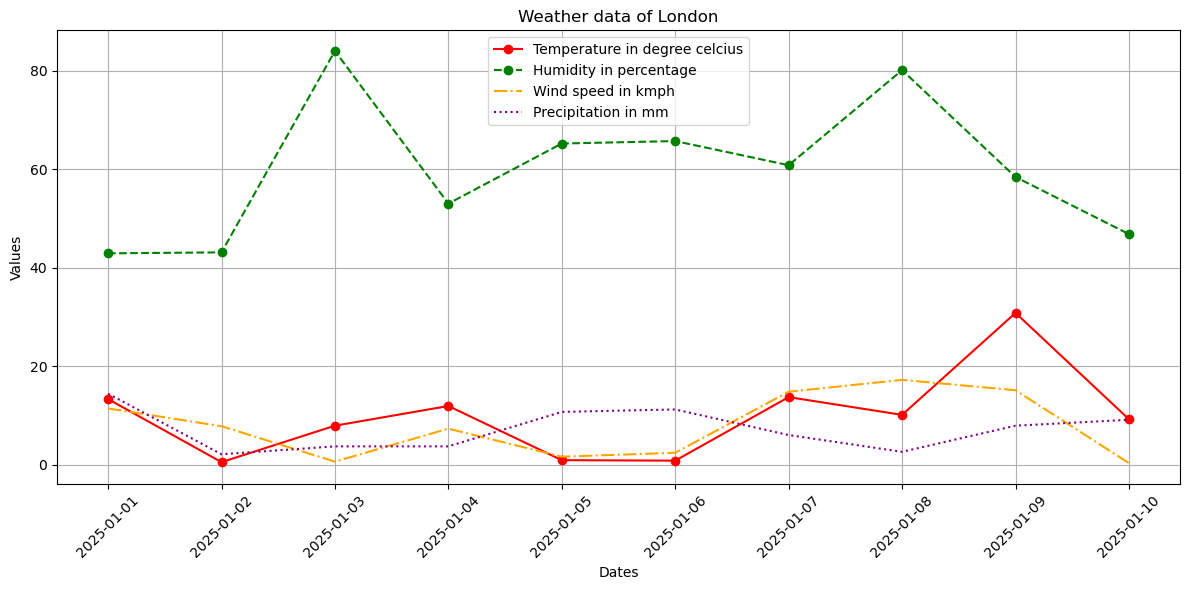

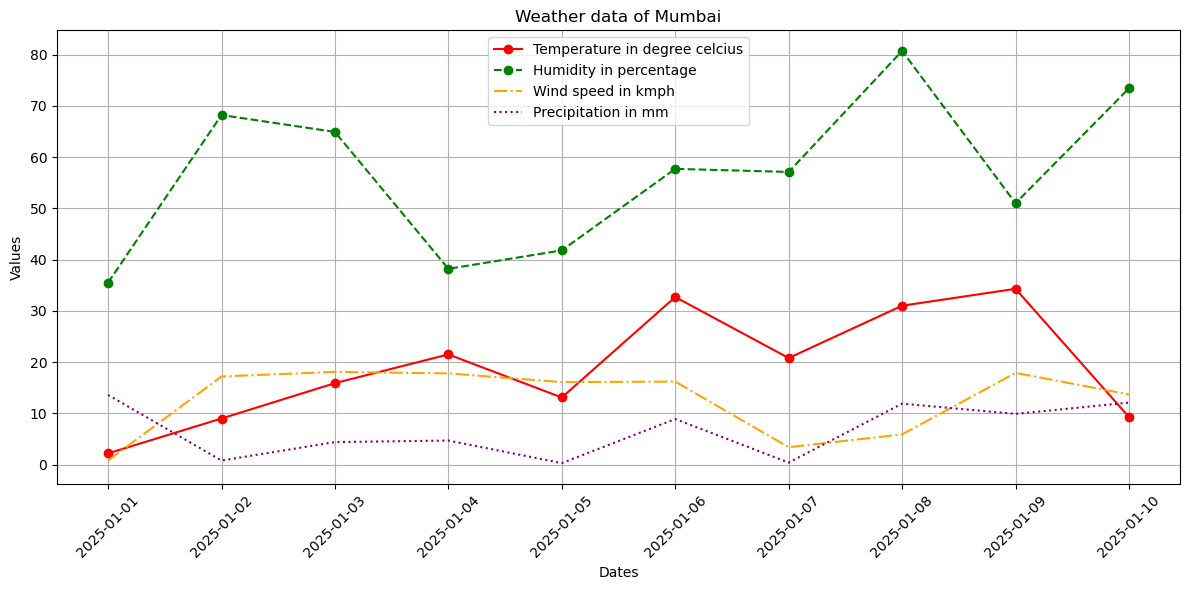

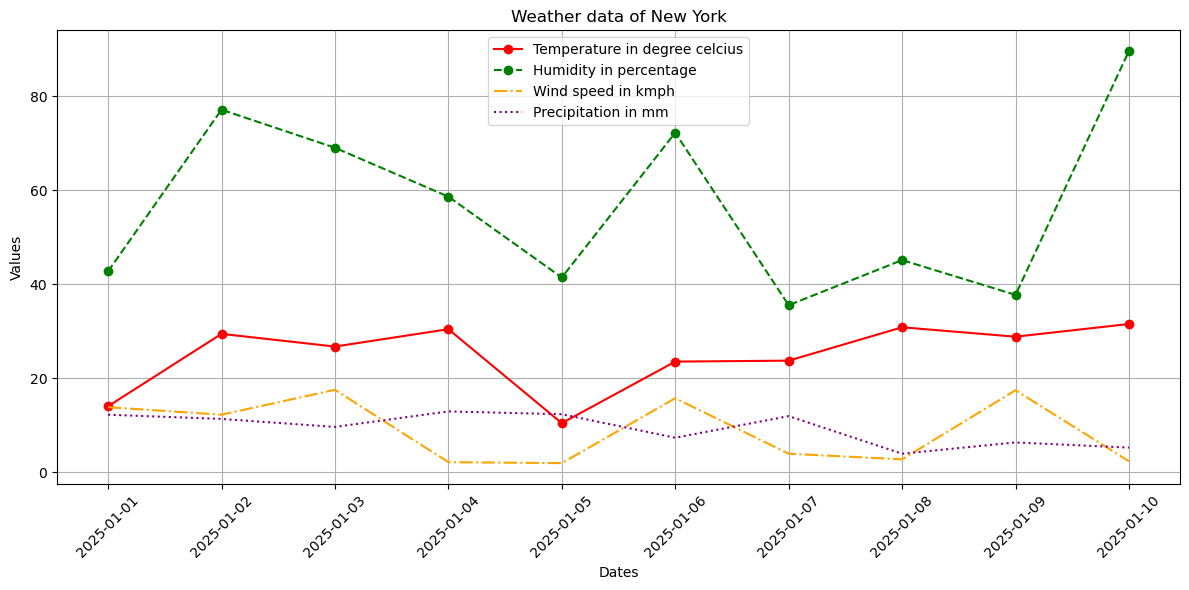

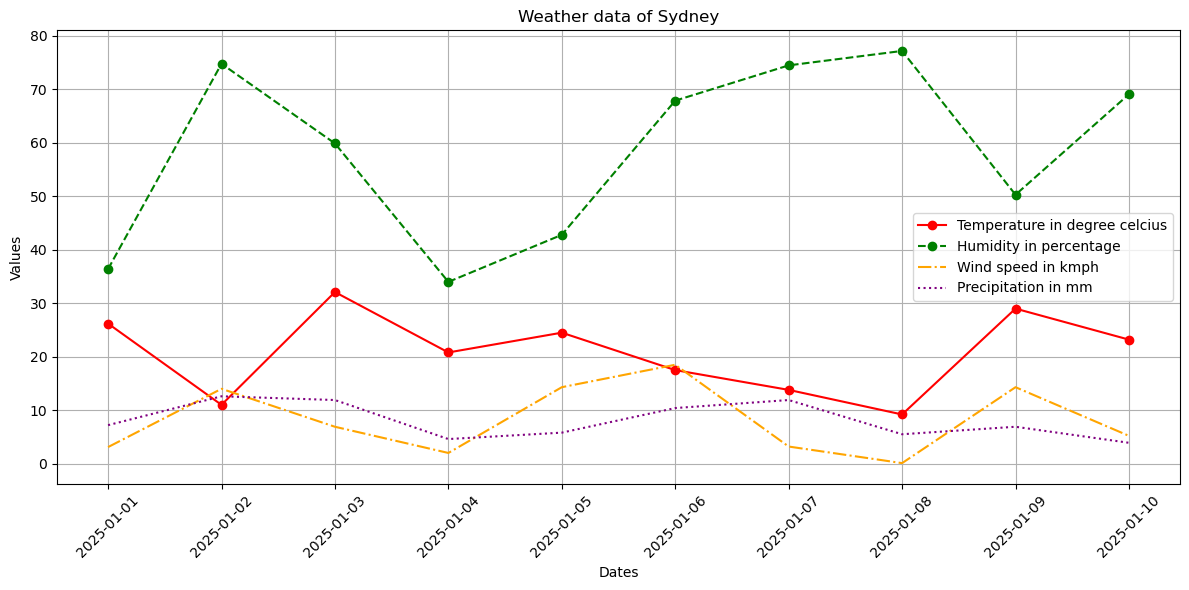

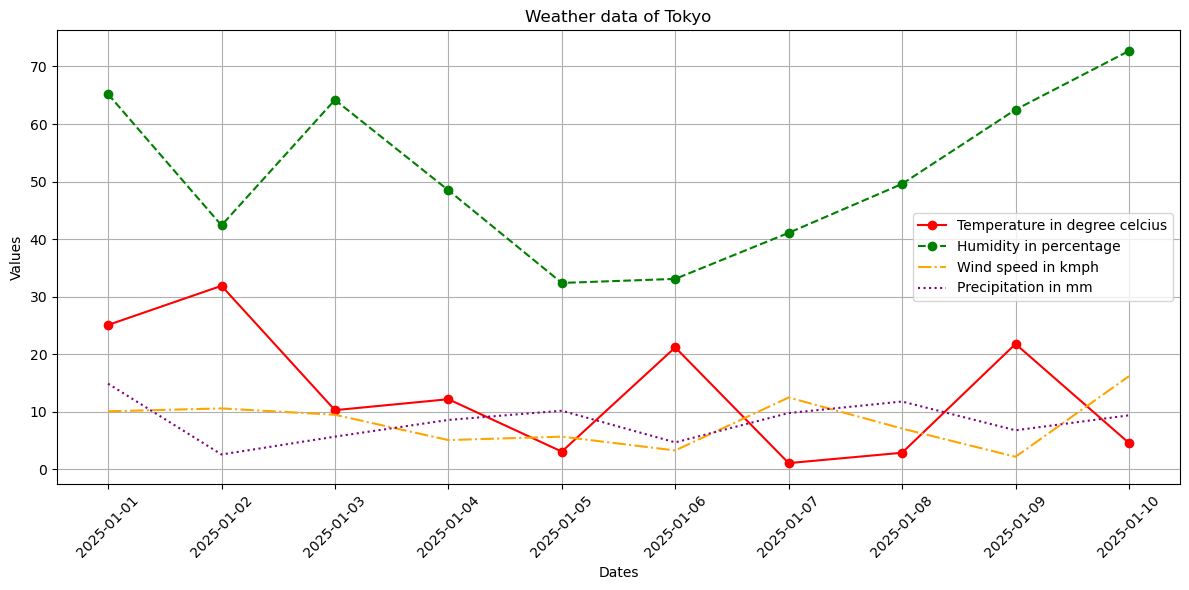

In [52]:
from matplotlib import pyplot as plt
for city, city_df in group_by_df2:
    plt.figure(figsize=(12,6))
    plt.plot(city_df["Date"],city_df["Temperature_C"],color="red",linestyle="-",marker="o",label="Temperature in degree celcius")
    plt.plot(city_df["Date"],city_df["Humidity_%"],color="green",linestyle="--",marker="o",label="Humidity in percentage")
    plt.plot(city_df["Date"],city_df["WindSpeed_kmph"],color="orange",linestyle="-.",label="Wind speed in kmph")
    plt.plot(city_df["Date"],city_df["Precipitation_mm"],color="purple",linestyle=":",label="Precipitation in mm")
    plt.title(f"Weather data of {city}")
    plt.xlabel("Dates")
    plt.ylabel("Values")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Plot all the temperature from all the cities in one graph to and draw comparision between them.
#### Method 1:
Create sub dataFrames for each city present in the group_by object of Pandas.

In [54]:
mumbai_df = group_by_df2.get_group("Mumbai")
mumbai_df

,City,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
30,Mumbai,2025-01-01,2.2,35.5,0.8,13.6
31,Mumbai,2025-01-02,9.0,68.2,17.2,0.8
32,Mumbai,2025-01-03,15.9,64.9,18.1,4.4
33,Mumbai,2025-01-04,21.5,38.2,17.8,4.7
34,Mumbai,2025-01-05,13.1,41.8,16.1,0.3
35,Mumbai,2025-01-06,32.7,57.7,16.2,8.9
36,Mumbai,2025-01-07,20.8,57.1,3.4,0.4
37,Mumbai,2025-01-08,31.0,80.7,5.9,11.9
38,Mumbai,2025-01-09,34.3,51.0,17.9,9.9
39,Mumbai,2025-01-10,9.3,73.4,13.7,12.1


In [55]:
tokyo_df = group_by_df2.get_group("Tokyo")
tokyo_df

,City,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
20,Tokyo,2025-01-01,25.1,65.2,10.1,14.9
21,Tokyo,2025-01-02,31.9,42.4,10.6,2.6
22,Tokyo,2025-01-03,10.3,64.2,9.5,5.7
23,Tokyo,2025-01-04,12.2,48.5,5.1,8.6
24,Tokyo,2025-01-05,3.1,32.4,5.7,10.2
25,Tokyo,2025-01-06,21.2,33.1,3.3,4.7
26,Tokyo,2025-01-07,1.1,41.1,12.5,9.8
27,Tokyo,2025-01-08,2.9,49.6,7.1,11.8
28,Tokyo,2025-01-09,21.8,62.5,2.2,6.8
29,Tokyo,2025-01-10,4.6,72.7,16.2,9.4


In [56]:
sydney_df = group_by_df2.get_group("Sydney")
sydney_df

,City,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
40,Sydney,2025-01-01,26.2,36.4,3.1,7.2
41,Sydney,2025-01-02,11.0,74.8,14.0,12.6
42,Sydney,2025-01-03,32.1,59.9,6.9,11.9
43,Sydney,2025-01-04,20.8,34.0,2.0,4.6
44,Sydney,2025-01-05,24.5,42.8,14.3,5.8
45,Sydney,2025-01-06,17.5,67.9,18.5,10.4
46,Sydney,2025-01-07,13.8,74.5,3.2,11.9
47,Sydney,2025-01-08,9.2,77.2,0.1,5.5
48,Sydney,2025-01-09,29.0,50.3,14.3,6.9
49,Sydney,2025-01-10,23.2,69.1,5.2,3.9


In [57]:
london_df = group_by_df2.get_group("London")
london_df

,City,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
10,London,2025-01-01,13.3,42.9,11.4,14.4
11,London,2025-01-02,0.5,43.1,7.8,2.1
12,London,2025-01-03,7.9,84.0,0.6,3.7
13,London,2025-01-04,11.9,53.0,7.3,3.7
14,London,2025-01-05,0.9,65.2,1.6,10.7
15,London,2025-01-06,0.8,65.7,2.4,11.2
16,London,2025-01-07,13.7,60.8,14.8,6.0
17,London,2025-01-08,10.1,80.1,17.2,2.6
18,London,2025-01-09,30.8,58.4,15.1,7.9
19,London,2025-01-10,9.2,46.8,0.3,9.1


In [58]:
new_york_df = group_by_df2.get_group("New York")
new_york_df

,City,Date,Temperature_C,Humidity_%,WindSpeed_kmph,Precipitation_mm
0,New York,2025-01-01,14.0,42.7,13.8,12.2
1,New York,2025-01-02,29.4,77.1,12.2,11.3
2,New York,2025-01-03,26.7,69.0,17.5,9.6
3,New York,2025-01-04,30.4,58.6,2.1,12.9
4,New York,2025-01-05,10.4,41.4,1.9,12.3
5,New York,2025-01-06,23.5,72.2,15.7,7.3
6,New York,2025-01-07,23.7,35.5,3.9,11.9
7,New York,2025-01-08,30.8,45.1,2.7,3.9
8,New York,2025-01-09,28.8,37.7,17.4,6.3
9,New York,2025-01-10,31.5,89.6,2.3,5.2


#### Plotting temperature of each cities 

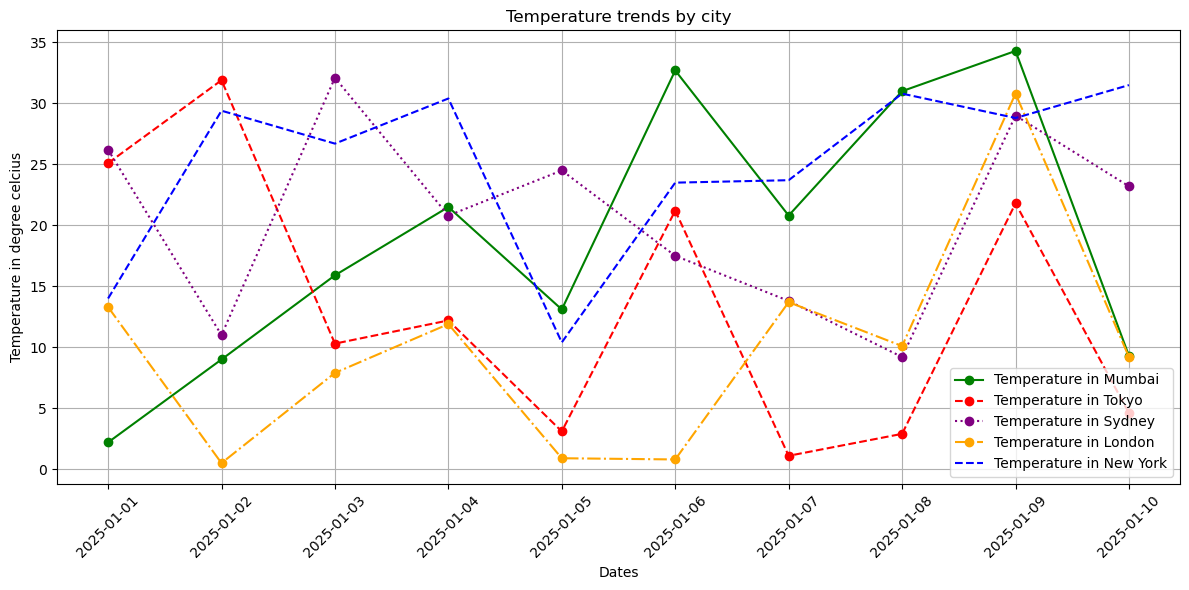

In [72]:
plt.figure(figsize=(12,6))
plt.plot(mumbai_df["Date"],mumbai_df["Temperature_C"],color="green",marker="o",linestyle="-",label="Temperature in Mumbai")
plt.plot(tokyo_df["Date"],tokyo_df["Temperature_C"],color="red",marker="o",linestyle="--",label="Temperature in Tokyo")
plt.plot(sydney_df["Date"],sydney_df["Temperature_C"],color="purple",marker="o",linestyle=":",label="Temperature in Sydney")
plt.plot(london_df["Date"],london_df["Temperature_C"],color="orange",marker="o",linestyle="-.",label="Temperature in London")
plt.plot(new_york_df["Date"],new_york_df["Temperature_C"],color="blue",linestyle="--",label="Temperature in New York")
plt.title("Temperature trends by city")
plt.xlabel("Dates")
plt.ylabel("Temperature in degree celcius")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

#### Method 2:
Use for loop instead of creating separate dataFrames using get_group function 

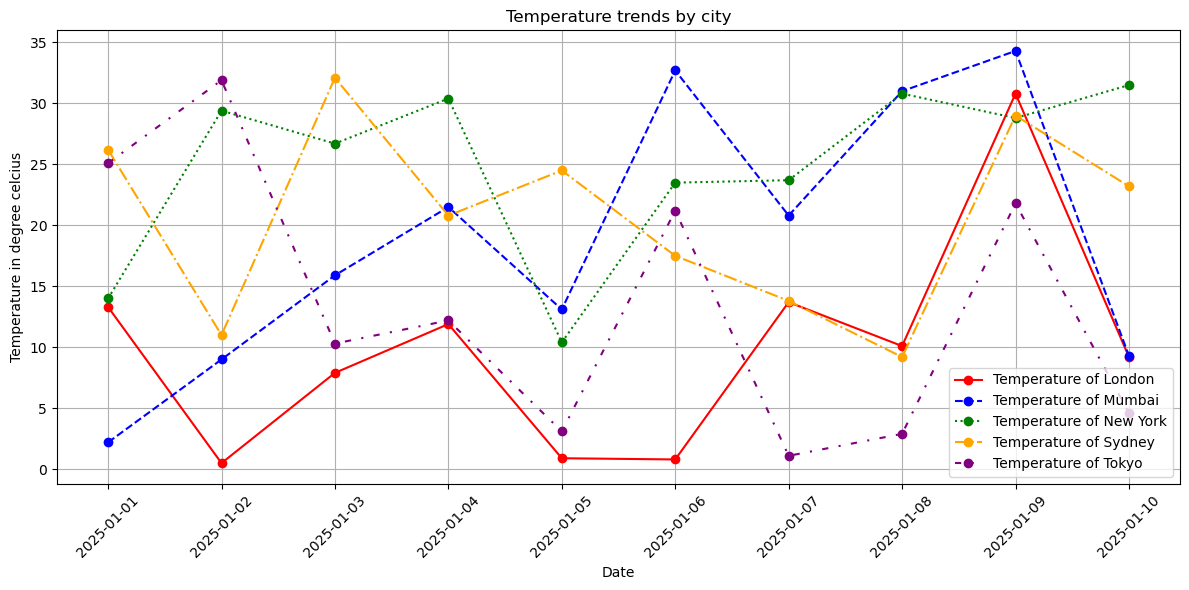

In [71]:
from matplotlib import pyplot as plt
import itertools
# line colors array
colors = ["red", "blue", "green", "orange", "purple", "brown", "cyan", "magenta"]
# line varity array
linestyles = ["-", "--", ":", "-.", (0,(3,5,1,5)), (0,(5,10))]

# create infinite cycling iterators
color_cycle = itertools.cycle(colors)
linestyle_cycle = itertools.cycle(linestyles)

plt.figure(figsize=(12,6))

for city, city_df in group_by_df2:
    plt.plot(city_df["Date"], city_df["Temperature_C"],marker="o",
            color=next(color_cycle), linestyle=next(linestyle_cycle), label = f"Temperature of {city}"
            )
plt.title("Temperature trends by city")
plt.xlabel("Date")
plt.ylabel("Temperature in degree celcius")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

### Explanation : 
#### What are itertools?
itertools is a standard python library module that provides fast memory-effitient tools for creating and using iterators. <br>
It's often used when: <br>
- You want to loop over items infinitely (cycle)
- You need combinations or permutations (combinations, permutations)
- You want to filter or group data effitiently
<br>
It's greate for :
- Repeating patterns (color, styles)
- Complex loops without creating big lists
- Lazy evaluations (only generating what's needed)
<br>
No installation required when it comes this itertools module.

#### What is ```itertools.cycle()```
```itertools.cycle(iterable)``` creates an infinite iterator that loops over the given interable forever. <br>
syntax : <br>
```cycle_value = itertools.cycle(a_list_of_value)``` <br>
This takes in a list as a parameter and it will keep giving you the values from the list one by one then when it reaches the last element in the list it then again goes back to the first element in the list and this cycle keeps on repeating itself infinitely. <br>
Here ```cycle_value``` is essentially an ```iterator```

#### What is ```next()``` ? 
```next(iterator)``` is a built-in python function that: <br>
- Gets the next item from an iterator.
- Moves the iterator's internal position forward.
<br>
If you call ```next()``` after it's exhausted (and It's not a cycle), you will get a StopIteration error.

#### when to use ```itertools.cycle()```?
Use ```cycle()``` when:
- You want to reuse a set of values indefinately without manually resetting an index.
- Examples:
  - Rotating plot colors/styles
  - cycles through player turns in a game
  - repeating an animation sequence
  - periodic events in simulations

#### Method 2 is much more effitient when compared to method 1 since I don't have to manually get all the dataFrames by city and plot the graph. 